# Lab 01 — Search Foundations on an Airline Network

**Worked Python solution.** This notebook implements and evaluates Breadth-First Search (BFS), Depth-First Search (DFS), and Uniform-Cost Search (UCS) on the supplied OpenFlights datasets.

### Learning outcomes
- clean a real graph dataset and define a consistent state space;
- implement/execute uninformed search with reproducible metrics;
- verify returned paths rather than trusting an algorithm blindly;
- interpret the difference between fewest hops and shortest geographic distance.

All generated evidence is written to `results/lab01/`.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

from search_toolkit import load_openflights, bfs, dfs, ucs, route_is_valid

RESULTS = ROOT / "results" / "lab01"
RESULTS.mkdir(parents=True, exist_ok=True)
AIRPORTS = ROOT / "all_datasets" / "lab01-03_airports.csv"
ROUTES = ROOT / "all_datasets" / "lab01-03_routes.csv"
QUERIES = ROOT / "config" / "search_queries.csv"

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE


## 1. Load and validate the graph

The supplied airport file is the headerless OpenFlights format. We assign the documented columns, retain valid three-character IATA codes with coordinates, and collapse duplicate route pairs. Edge cost is great-circle distance in kilometres.

In [2]:
airports, routes, coords, adjacency, stats = load_openflights(AIRPORTS, ROUTES)
pd.Series(stats, name="count").to_frame()

,count
airport_rows,10668
valid_airports,6464
route_rows,67663
unique_valid_routes,37338
removed_route_rows,30325


**Answer.** The cleaned graph intentionally contains fewer routes than the raw CSV because routes are removed when either endpoint lacks a usable IATA code/coordinate, and duplicate source–destination pairs are collapsed. This is necessary so all algorithms operate on the same well-defined graph.

## 2. Run the three standard queries

In [3]:
queries = pd.read_csv(QUERIES).head(3)
rows = []
paths = {}
for q in queries.itertuples(index=False):
    for name, func in [("BFS", bfs), ("DFS", dfs), ("UCS", ucs)]:
        r = func(adjacency, q.start, q.goal)
        assert r.found
        assert route_is_valid(r.path, adjacency)
        rows.append({
            "query_id": q.query_id, "start": q.start, "goal": q.goal,
            "algorithm": name, "found": r.found, "hops": r.hops,
            "path_cost_km": r.path_cost_km, "expanded": r.expanded,
            "max_frontier": r.max_frontier, "runtime_ms": r.runtime_ms,
            "path": " -> ".join(r.path),
        })
        paths[(q.query_id, name)] = r.path
metrics = pd.DataFrame(rows)
metrics.to_csv(RESULTS / "metrics.csv", index=False)
metrics[["query_id","algorithm","hops","path_cost_km","expanded","max_frontier","runtime_ms"]].round(2)

,query_id,algorithm,hops,path_cost_km,expanded,max_frontier,runtime_ms
0,Q1,BFS,2,12274.32,6,279,5.41
1,Q1,DFS,23,41767.82,2113,859,5.78
2,Q1,UCS,4,11461.35,1852,616,6.84
3,Q2,BFS,2,21976.11,5,229,5.47
4,Q2,DFS,39,65213.84,905,858,7.89
5,Q2,UCS,3,17817.36,3003,620,7.81
6,Q3,BFS,2,19005.89,3,171,4.91
7,Q3,DFS,64,91541.43,1415,785,5.08
8,Q3,UCS,3,14813.32,3043,1018,13.70


## 3. Verify path costs independently

In [4]:
edge_lookup = {u: dict(vs) for u, vs in adjacency.items()}
checks = []
for row in metrics.itertuples(index=False):
    path = row.path.split(" -> ")
    summed = sum(edge_lookup[u][v] for u, v in zip(path, path[1:]))
    checks.append(abs(summed - row.path_cost_km) < 1e-8)
assert all(checks)
print(f"Verified {len(checks)} paths: every edge exists and every reported cost matches the edge sum.")

Verified 9 paths: every edge exists and every reported cost matches the edge sum.


## 4. Visual evidence for KUL → KEF

This is not a geographic map projection; it is a longitude/latitude route sketch used to compare the paths returned by the three algorithms.

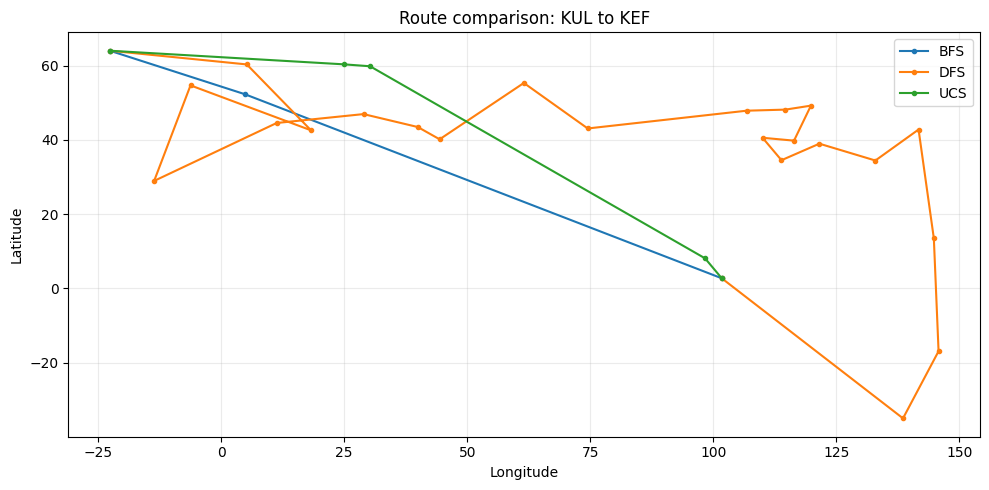

In [5]:
q = queries.iloc[0]
fig, ax = plt.subplots(figsize=(10,5))
for name in ["BFS","DFS","UCS"]:
    path = paths[(q.query_id, name)]
    xs = [coords[a]["longitude"] for a in path]
    ys = [coords[a]["latitude"] for a in path]
    ax.plot(xs, ys, marker="o", linewidth=1.5, markersize=3, label=name)
ax.set(title=f"Route comparison: {q.start} to {q.goal}", xlabel="Longitude", ylabel="Latitude")
ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
fig.savefig(RESULTS / "route_comparison.png", dpi=160)
plt.show()

## Worked interpretation

For these airline routes, **BFS optimizes hop count, not distance**. It can therefore prefer a two-flight itinerary through a distant hub even when UCS finds a longer-hop but geographically shorter route. **DFS is highly traversal-order dependent** and is unsuitable when route quality matters; it often returns a much longer path. **UCS is the correct uninformed method when edge cost represents distance**, because it expands paths in increasing accumulated cost.

The important engineering point is that “shortest path” is meaningless until the cost definition is stated explicitly.

### Submission evidence
- `results/lab01/metrics.csv`
- `results/lab01/route_comparison.png`
- this executed notebook

Re-run the notebook from the project root before submission; no cell should depend on hidden state.